/var/folders/wf/99_6t8ks1k9d8j0hnn8j65gc0000gn/T/ipykernel_14422/1518263205.py:8: DtypeWarning: Columns (0: terminal_observation) have mixed types. Specify dtype option on import or set low_memory=False.
  ppo = pd.read_csv("ppo_rl_simulation_output.csv")
/var/folders/wf/99_6t8ks1k9d8j0hnn8j65gc0000gn/T/ipykernel_14422/1518263205.py:9: DtypeWarning: Columns (0: terminal_observation) have mixed types. Specify dtype option on import or set low_memory=False.
  sac = pd.read_csv("sac_rl_simulation_output.csv")
/var/folders/wf/99_6t8ks1k9d8j0hnn8j65gc0000gn/T/ipykernel_14422/1518263205.py:10: DtypeWarning: Columns (0: terminal_observation) have mixed types. Specify dtype option on import or set low_memory=False.
  a2c = pd.read_csv("a2c_rl_simulation_output.csv")


PPO: (500000, 17)
SAC: (500000, 17)
A2C: (500000, 17)

📊 ===== BASIC METRICS =====

PPO:
Avg Profit: 293.1628849374815
Total Profit: 146581442.46874076
Avg Revenue: 703.0882310327534
Avg Price: 23.958077437164576

SAC:
Avg Profit: 269.66216949146684
Total Profit: 134831084.7457334
Avg Revenue: 756.5816417838383
Avg Price: 21.903036367819308

A2C:
Avg Profit: 293.8384121435773
Total Profit: 146919206.07178864
Avg Revenue: 700.0943586463263
Avg Price: 24.133802008002917

🏆 Best Model (by Avg Profit): A2C


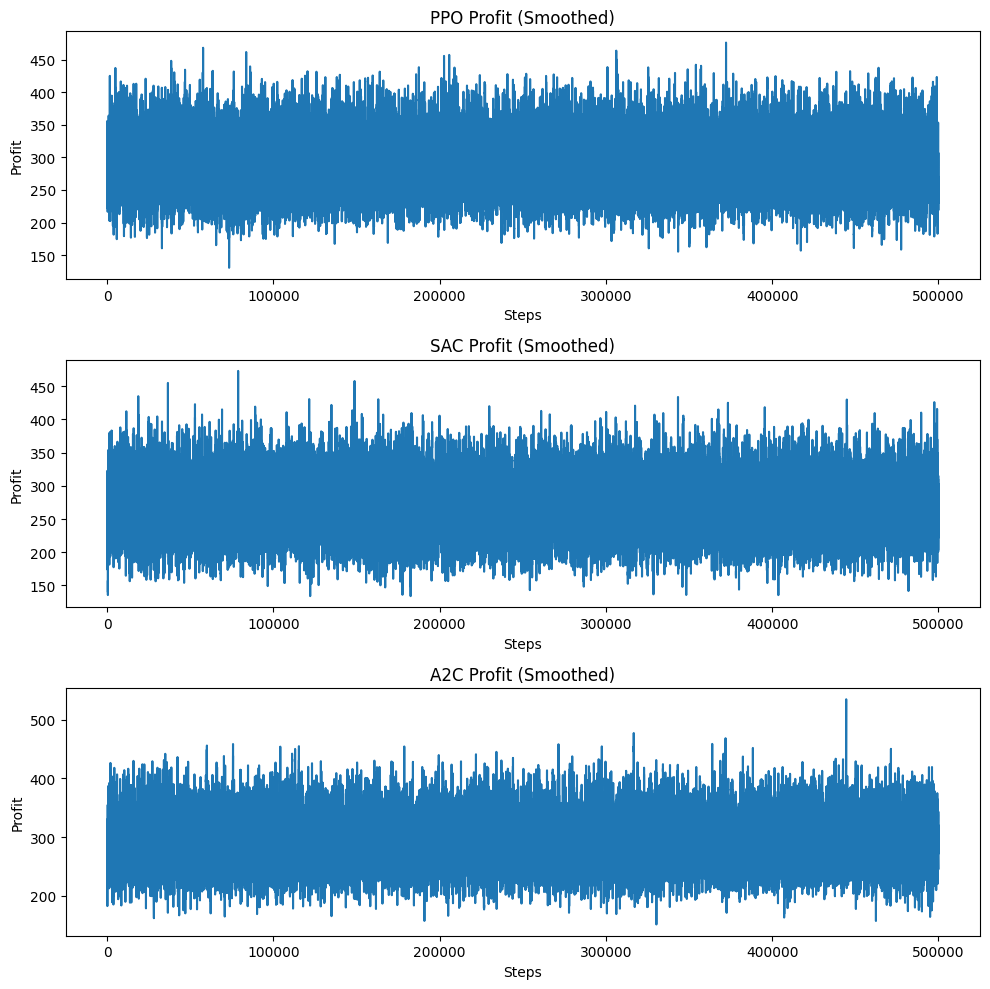

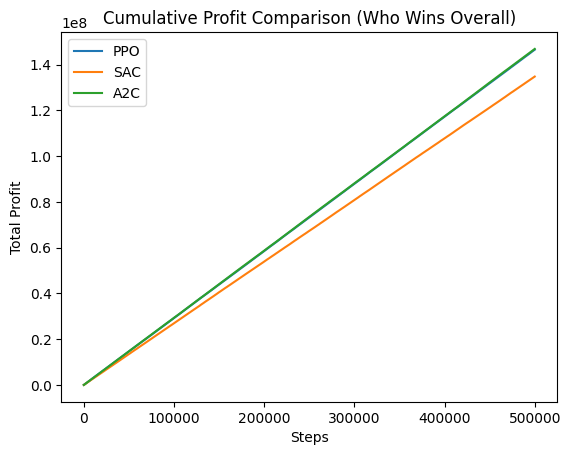

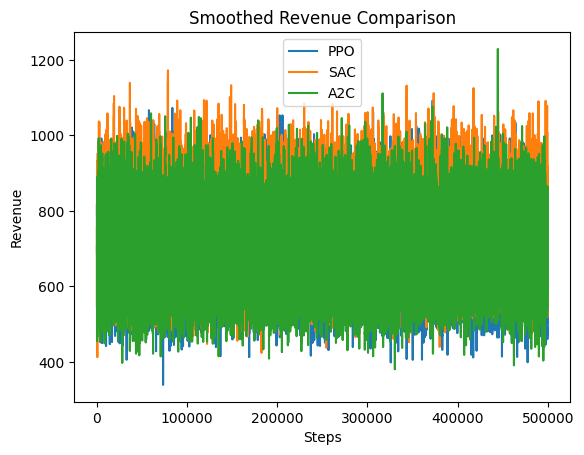

/var/folders/wf/99_6t8ks1k9d8j0hnn8j65gc0000gn/T/ipykernel_14422/1518263205.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_data, labels=models.keys())


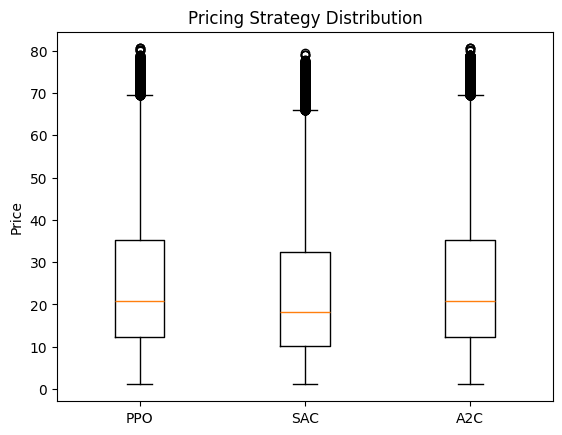

/var/folders/wf/99_6t8ks1k9d8j0hnn8j65gc0000gn/T/ipykernel_14422/1518263205.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(profit_data, labels=models.keys())


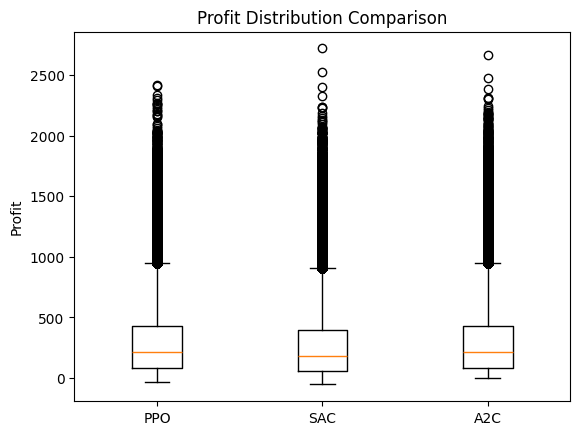

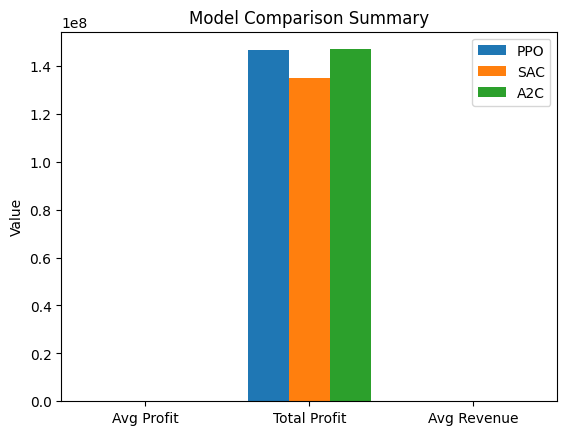


📉 ===== STABILITY =====
PPO Profit Std Dev: 270.2952519683832
SAC Profit Std Dev: 266.7550219784003
A2C Profit Std Dev: 270.40797014778684

📊 ===== SUMMARY TABLE =====
         Metric           PPO           SAC           A2C
0    Avg Profit  2.931629e+02  2.696622e+02  2.938384e+02
1  Total Profit  1.465814e+08  1.348311e+08  1.469192e+08
2   Avg Revenue  7.030882e+02  7.565816e+02  7.000944e+02
3     Avg Price  2.395808e+01  2.190304e+01  2.413380e+01


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 📂 LOAD ALL MODELS
# ===============================

ppo = pd.read_csv("ppo_rl_simulation_output.csv")
sac = pd.read_csv("sac_rl_simulation_output.csv")
a2c = pd.read_csv("a2c_rl_simulation_output.csv")

print("PPO:", ppo.shape)
print("SAC:", sac.shape)
print("A2C:", a2c.shape)

# Store in dict for cleaner code
models = {
    "PPO": ppo,
    "SAC": sac,
    "A2C": a2c
}

# ===============================
# 📊 BASIC METRICS
# ===============================

print("\n📊 ===== BASIC METRICS =====")

for name, df in models.items():
    print(f"\n{name}:")
    print("Avg Profit:", df["profit"].mean())
    print("Total Profit:", df["profit"].sum())
    print("Avg Revenue:", df["revenue"].mean())
    print("Avg Price:", df["chosen_price"].mean())

# ===============================
# 📊 IMPROVEMENT (BEST MODEL)
# ===============================

avg_profits = {name: df["profit"].mean() for name, df in models.items()}
best_model = max(avg_profits, key=avg_profits.get)

print("\n🏆 Best Model (by Avg Profit):", best_model)

# ===============================
# 📈 IMPROVED VISUALIZATIONS
# ===============================

window = 50  # smoothing window

# -------------------------------
# 1. SMOOTHED PROFIT (SUBPLOTS)
# -------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

for ax, (name, df) in zip(axes, models.items()):
    smoothed = df["profit"].rolling(window).mean()
    ax.plot(smoothed)
    ax.set_title(f"{name} Profit (Smoothed)")
    ax.set_xlabel("Steps")
    ax.set_ylabel("Profit")

plt.tight_layout()
plt.show()

# -------------------------------
# 2. CUMULATIVE PROFIT (VERY IMPORTANT)
# -------------------------------
plt.figure()

for name, df in models.items():
    cumulative = df["profit"].cumsum()
    plt.plot(cumulative, label=name)

plt.legend()
plt.title("Cumulative Profit Comparison (Who Wins Overall)")
plt.xlabel("Steps")
plt.ylabel("Total Profit")
plt.show()

# -------------------------------
# 3. REVENUE (SMOOTHED)
# -------------------------------
plt.figure()

for name, df in models.items():
    smoothed = df["revenue"].rolling(window).mean()
    plt.plot(smoothed, label=name)

plt.legend()
plt.title("Smoothed Revenue Comparison")
plt.xlabel("Steps")
plt.ylabel("Revenue")
plt.show()

# -------------------------------
# 4. PRICE DISTRIBUTION (BOXPLOT)
# -------------------------------
plt.figure()

price_data = [df["chosen_price"] for df in models.values()]
plt.boxplot(price_data, labels=models.keys())

plt.title("Pricing Strategy Distribution")
plt.ylabel("Price")
plt.show()

# -------------------------------
# 5. PROFIT DISTRIBUTION (BOXPLOT)
# -------------------------------
plt.figure()

profit_data = [df["profit"] for df in models.values()]
plt.boxplot(profit_data, labels=models.keys())

plt.title("Profit Distribution Comparison")
plt.ylabel("Profit")
plt.show()

# -------------------------------
# 6. BAR CHART (QUICK SUMMARY)
# -------------------------------
metrics = ["Avg Profit", "Total Profit", "Avg Revenue"]

values = [
    [ppo["profit"].mean(), ppo["profit"].sum(), ppo["revenue"].mean()],
    [sac["profit"].mean(), sac["profit"].sum(), sac["revenue"].mean()],
    [a2c["profit"].mean(), a2c["profit"].sum(), a2c["revenue"].mean()]
]

import numpy as np

x = np.arange(len(metrics))
width = 0.25

plt.figure()

plt.bar(x - width, values[0], width, label="PPO")
plt.bar(x, values[1], width, label="SAC")
plt.bar(x + width, values[2], width, label="A2C")

plt.xticks(x, metrics)
plt.legend()
plt.title("Model Comparison Summary")
plt.ylabel("Value")

plt.show()

# ===============================
# 📉 STABILITY (VERY IMPORTANT)
# ===============================

print("\n📉 ===== STABILITY =====")

for name, df in models.items():
    print(f"{name} Profit Std Dev:", df["profit"].std())

# ===============================
# 📊 SUMMARY TABLE
# ===============================

summary = pd.DataFrame({
    "Metric": ["Avg Profit", "Total Profit", "Avg Revenue", "Avg Price"],
    "PPO": [
        ppo["profit"].mean(),
        ppo["profit"].sum(),
        ppo["revenue"].mean(),
        ppo["chosen_price"].mean()
    ],
    "SAC": [
        sac["profit"].mean(),
        sac["profit"].sum(),
        sac["revenue"].mean(),
        sac["chosen_price"].mean()
    ],
    "A2C": [
        a2c["profit"].mean(),
        a2c["profit"].sum(),
        a2c["revenue"].mean(),
        a2c["chosen_price"].mean()
    ]
})

print("\n📊 ===== SUMMARY TABLE =====")
print(summary)